# Yearly Behavioral Perspective
## Data Mining Project
------
**Group 12:**

- Luis Mendes 20221949
- Margarida Mourives 20221809
- Simon Sazonov 20221689 
- Veronica Mendes 20221945

----

## Summary

Yearly behavioral segmentation, analyzing purchasing habits and travel behaviors.

<a class="anchor" id='toc'></a> 
<div class="alert alert-block alert-info">

## **Index**<br>

[**Imports**](#1st-bullet)<br>

[**Data Preposessing**](#2nd-bullet)<br>

    
</div>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
import warnings
import umap

from sklearn.preprocessing import RobustScaler, MinMaxScaler

from sklearn.metrics import silhouette_score, silhouette_samples # new library
from sklearn.cluster import KMeans # new library
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.cm as cm


warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

sns.set_context("notebook")
sns.set_style("ticks")

In [262]:
df_AIAI_Master_Complete = pd.read_csv('../data/DM_AIAI_MasterCustomerDB.csv', index_col=0,
                                      parse_dates=['EnrollmentDateOpening', 'CancellationDate'])
df_AIAI_Master = df_AIAI_Master_Complete.copy()



In [ ]:
Behavioral_columns = df_AIAI_Master.columns.to_list()[-60:]

df_AIAI_Behavioral = df_AIAI_Master[Behavioral_columns].copy()
df_AIAI_Behavioral.head()

,Total_NumFlights_2019,Total_NumFlights_2020,Total_NumFlights_2021,Total_DistanceKM_2019,Total_DistanceKM_2020,Total_DistanceKM_2021,Perc_Flights_With_Companions_2019,Perc_Flights_With_Companions_2020,Perc_Flights_With_Companions_2021,Dollar_Cost_Points_Remaining_2019,Dollar_Cost_Points_Remaining_2020,Dollar_Cost_Points_Remaining_2021,Total_NumFlights_month_1,Total_NumFlights_month_2,Total_NumFlights_month_3,Total_NumFlights_month_4,Total_NumFlights_month_5,Total_NumFlights_month_6,Total_NumFlights_month_7,Total_NumFlights_month_8,Total_NumFlights_month_9,Total_NumFlights_month_10,Total_NumFlights_month_11,Total_NumFlights_month_12,Total_DistanceKM_month_1,Total_DistanceKM_month_2,Total_DistanceKM_month_3,Total_DistanceKM_month_4,Total_DistanceKM_month_5,Total_DistanceKM_month_6,Total_DistanceKM_month_7,Total_DistanceKM_month_8,Total_DistanceKM_month_9,Total_DistanceKM_month_10,Total_DistanceKM_month_11,Total_DistanceKM_month_12,Perc_Flights_With_Companions_month_1,Perc_Flights_With_Companions_month_2,Perc_Flights_With_Companions_month_3,Perc_Flights_With_Companions_month_4,Perc_Flights_With_Companions_month_5,Perc_Flights_With_Companions_month_6,Perc_Flights_With_Companions_month_7,Perc_Flights_With_Companions_month_8,Perc_Flights_With_Companions_month_9,Perc_Flights_With_Companions_month_10,Perc_Flights_With_Companions_month_11,Perc_Flights_With_Companions_month_12,Dollar_Cost_Points_Remaining_month_1,Dollar_Cost_Points_Remaining_month_2,Dollar_Cost_Points_Remaining_month_3,Dollar_Cost_Points_Remaining_month_4,Dollar_Cost_Points_Remaining_month_5,Dollar_Cost_Points_Remaining_month_6,Dollar_Cost_Points_Remaining_month_7,Dollar_Cost_Points_Remaining_month_8,Dollar_Cost_Points_Remaining_month_9,Dollar_Cost_Points_Remaining_month_10,Dollar_Cost_Points_Remaining_month_11,Dollar_Cost_Points_Remaining_month_12
Loyalty#,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
480934,59.0,64.0,68.0,116079.0,128976.0,252320.0,28.813559,29.687500,29.411765,94.4694,104.95,162.72,2.0,8.0,2.0,13.0,32.0,24.0,30.0,31.0,17.0,8.0,15.0,9.0,25173.0,65501.0,12324.0,4840.0,69191.0,43891.0,49709.0,44944.0,44545.0,70952.0,21244.0,45061.0,0.000000,25.000000,100.000000,23.076923,31.250000,0.000000,0.0,35.483871,58.823529,50.000000,73.333333,33.333333,25.1700,65.4939,12.3200,4.8400,69.1890,43.8785,49.7040,44.9366,44.5399,33.8046,-24.3761,-7.3610
549612,89.0,99.0,91.0,127972.0,142191.0,119776.0,7.865169,8.080808,18.681319,67.8339,75.33,22.10,24.0,17.0,32.0,10.0,42.0,12.0,36.0,36.0,10.0,28.0,21.0,11.0,26197.0,26125.0,28793.0,9958.0,58007.0,3077.0,39929.0,76785.0,24325.0,33704.0,35889.0,27150.0,25.000000,0.000000,0.000000,30.000000,0.000000,41.666667,25.0,25.000000,0.000000,0.000000,0.000000,0.000000,-0.6498,26.1250,28.7843,9.9500,57.9989,3.0700,-157.8262,76.7735,24.3200,33.6881,35.8801,27.1500
429460,54.0,60.0,6.0,97691.0,108547.0,23583.0,35.185185,35.000000,0.000000,71.7363,79.66,23.58,21.0,8.0,15.0,0.0,23.0,0.0,0.0,21.0,15.0,0.0,15.0,2.0,66764.0,6097.0,30356.0,0.0,6110.0,0.0,0.0,16881.0,56823.0,0.0,1030.0,45760.0,0.000000,75.000000,86.666667,0.000000,8.695652,0.000000,0.0,80.952381,0.000000,0.000000,0.000000,100.000000,66.7543,-48.7079,30.3493,0.0000,6.1044,0.0000,0.0000,16.8765,56.8163,0.0000,1.0278,45.7556
608370,73.0,81.0,42.0,143467.0,159407.0,83156.0,30.136986,30.864198,26.190476,82.0413,91.12,49.48,11.0,21.0,31.0,13.0,24.0,37.0,0.0,0.0,19.0,22.0,2.0,16.0,49255.0,35206.0,65665.0,37464.0,38224.0,45139.0,0.0,0.0,9285.0,53130.0,29241.0,23421.0,72.727273,52.380952,41.935484,0.000000,16.666667,0.000000,0.0,0.000000,10.526316,59.090909,0.000000,43.750000,-13.7374,-31.4985,65.6521,37.4562,38.2229,45.1288,0.0000,0.0000,9.2783,53.1249,29.2410,-10.2270
530508,39.0,43.0,89.0,126360.0,140400.0,99853.0,48.717949,48.837209,25.842697,126.3600,140.37,99.81,0.0,22.0,4.0,0.0,24.0,15.0,21.0,38.0,8.0,0.0,24.0,15.0,0.0,19731.0,5566.0,0.0,47106.0,54063.0,55404.0,73431.0,68327.0,0.0,40863.0,2122.0,0.000000,40.909091,100.000000,0.000000,25.000000,60.000000,0.0,34.210

# By year

In [265]:
df_AIAI_Behavioral_year = df_AIAI_Behavioral[df_AIAI_Behavioral.columns.to_list()[:12]].copy()
df_AIAI_Behavioral_year.head()

,Total_NumFlights_2019,Total_NumFlights_2020,Total_NumFlights_2021,Total_DistanceKM_2019,Total_DistanceKM_2020,Total_DistanceKM_2021,Perc_Flights_With_Companions_2019,Perc_Flights_With_Companions_2020,Perc_Flights_With_Companions_2021,Dollar_Cost_Points_Remaining_2019,Dollar_Cost_Points_Remaining_2020,Dollar_Cost_Points_Remaining_2021
Loyalty#,,,,,,,,,,,,
480934,59.0,64.0,68.0,116079.0,128976.0,252320.0,28.813559,29.687500,29.411765,94.4694,104.95,162.72
549612,89.0,99.0,91.0,127972.0,142191.0,119776.0,7.865169,8.080808,18.681319,67.8339,75.33,22.10
429460,54.0,60.0,6.0,97691.0,108547.0,23583.0,35.185185,35.000000,0.000000,71.7363,79.66,23.58
608370,73.0,81.0,42.0,143467.0,159407.0,83156.0,30.136986,30.864198,26.190476,82.0413,91.12,49.48
530508,39.0,43.0,89.0,126360.0,140400.0,99853.0,48.717949,48.837209,25.842697,126.3600,140.37,99.81


In [266]:
df_AIAI_Behavioral_year.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16572 entries, 480934 to 652627
Data columns (total 12 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Total_NumFlights_2019              15101 non-null  float64
 1   Total_NumFlights_2020              15101 non-null  float64
 2   Total_NumFlights_2021              15101 non-null  float64
 3   Total_DistanceKM_2019              15101 non-null  float64
 4   Total_DistanceKM_2020              15101 non-null  float64
 5   Total_DistanceKM_2021              15101 non-null  float64
 6   Perc_Flights_With_Companions_2019  15101 non-null  float64
 7   Perc_Flights_With_Companions_2020  15101 non-null  float64
 8   Perc_Flights_With_Companions_2021  15101 non-null  float64
 9   Dollar_Cost_Points_Remaining_2019  15101 non-null  float64
 10  Dollar_Cost_Points_Remaining_2020  15101 non-null  float64
 11  Dollar_Cost_Points_Remaining_2021  15101 non-null  fl

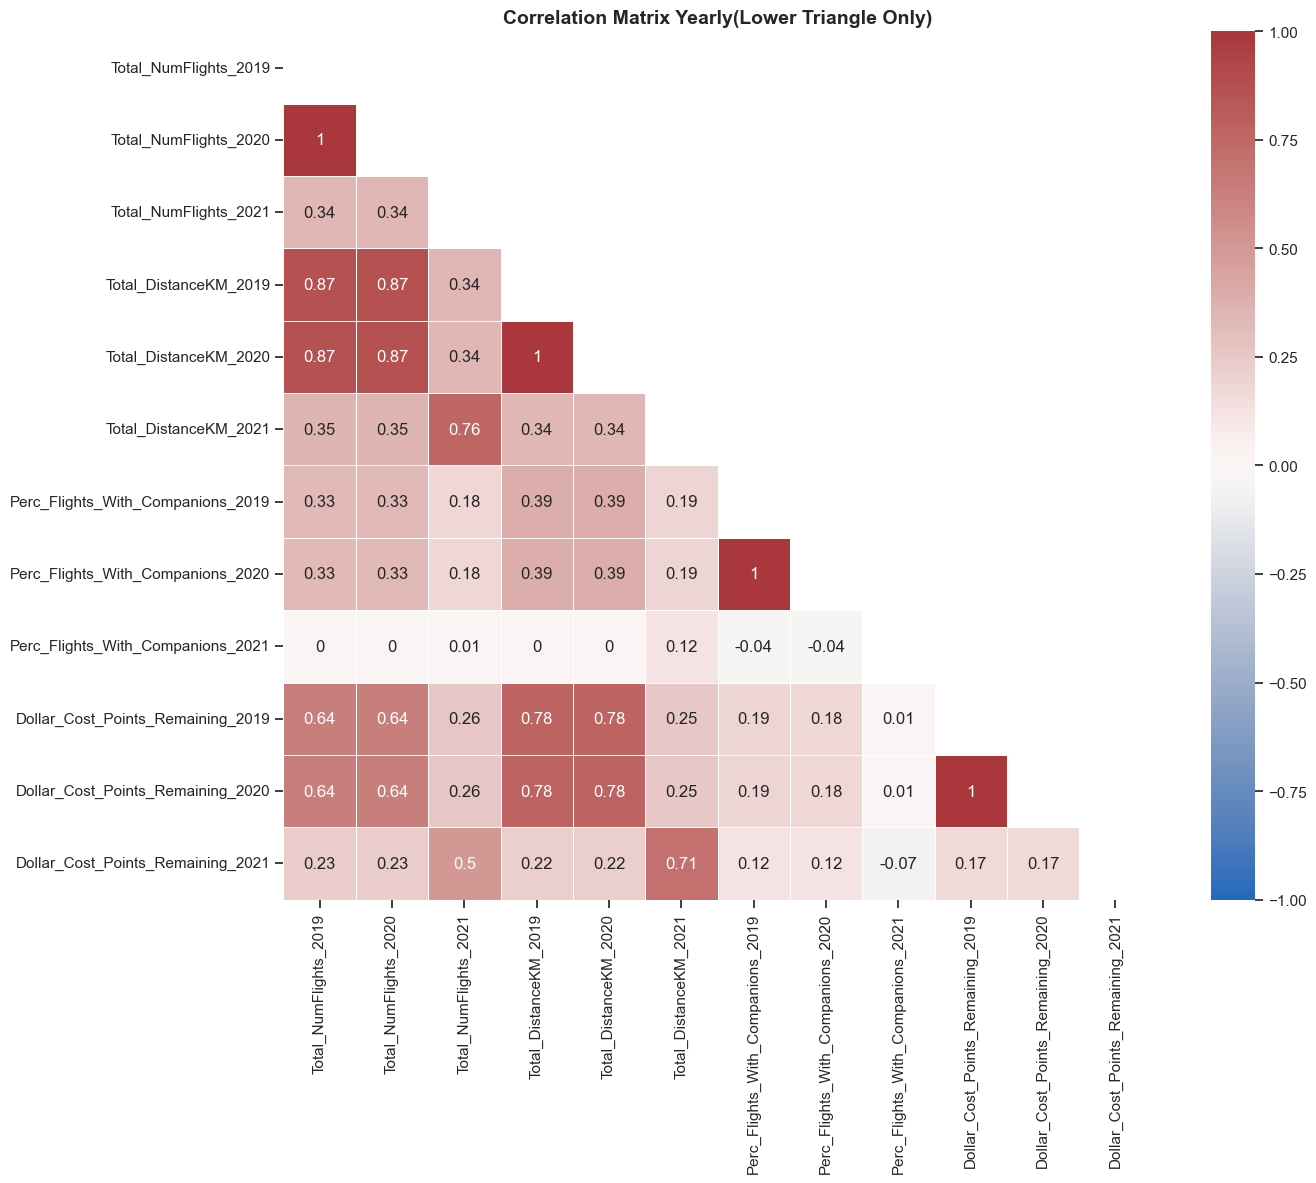

In [267]:
# Compute Pearson correlation
corr = df_AIAI_Behavioral_year.corr(method="pearson")
# Round to 2 decimals for cleaner display
corr = corr.round(2)

# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

fig = plt.figure(figsize=(15, 12))

sns.heatmap(data=corr, 
            annot=True, 
            mask=mask, #aply the mask
            vmin=-1, vmax=1, 
            center=0, # Center the colormap at zero
            square=True, # Make each cell square-shaped
            linewidths=.5, # Add lines between cells
            cmap='vlag' # Diverging color map
            )

plt.title("Correlation Matrix Yearly(Lower Triangle Only)", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

The number of flights in 2020 and 2019 had a perfect positive correlation, also the distance on those  years, the percentage of companions on those years and the dollarcostpointsremaining, so we will discard one of the years since they have the same information to create the clusters (to analyze them we can still have them). <br>
So we will discard 2019: total number of flighs, total distance, perc flights with companions and dollar cost points.  

In [268]:
# Drop 2019 columns due to high correlation with 2020
columns_to_drop = ['Total_NumFlights_2019', 'Total_DistanceKM_2019', 'Perc_Flights_With_Companions_2019', 'Dollar_Cost_Points_Remaining_2019']
df_AIAI_Behavioral_year = df_AIAI_Behavioral_year.drop(columns=columns_to_drop)

In [269]:
df_AIAI_Behavioral_year.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16572 entries, 480934 to 652627
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Total_NumFlights_2020              15101 non-null  float64
 1   Total_NumFlights_2021              15101 non-null  float64
 2   Total_DistanceKM_2020              15101 non-null  float64
 3   Total_DistanceKM_2021              15101 non-null  float64
 4   Perc_Flights_With_Companions_2020  15101 non-null  float64
 5   Perc_Flights_With_Companions_2021  15101 non-null  float64
 6   Dollar_Cost_Points_Remaining_2020  15101 non-null  float64
 7   Dollar_Cost_Points_Remaining_2021  15101 non-null  float64
dtypes: float64(8)
memory usage: 1.1 MB


We successfully deleted the 2019 columns due to high correlation with 2020.

In [270]:
df_AIAI_Behavioral_year.isna().sum()

Total_NumFlights_2020                1471
Total_NumFlights_2021                1471
Total_DistanceKM_2020                1471
Total_DistanceKM_2021                1471
Perc_Flights_With_Companions_2020    1471
Perc_Flights_With_Companions_2021    1471
Dollar_Cost_Points_Remaining_2020    1471
Dollar_Cost_Points_Remaining_2021    1471
dtype: int64

We identified customers with missing values (no transactions) and we are goint to filtered them out to ensure complete data for clustering algorithms. We are going to put this group of no transactions in the final cluster analysis. 


In [271]:
# Filter rows with any missing values into a new dataframe and add No_transactions (count of missing per row)
df_AIAI_Y_Behavioral_classified = df_AIAI_Behavioral_year[df_AIAI_Behavioral_year.isna().any(axis=1)].copy()

df_AIAI_Y_Behavioral_classified['Final_Cluster'] = 'No_transactions'

# Remove those observations from the original dataframe
df_AIAI_Behavioral_year = df_AIAI_Behavioral_year.drop(df_AIAI_Y_Behavioral_classified.index)


df_AIAI_Y_Behavioral_classified.head()


,Total_NumFlights_2020,Total_NumFlights_2021,Total_DistanceKM_2020,Total_DistanceKM_2021,Perc_Flights_With_Companions_2020,Perc_Flights_With_Companions_2021,Dollar_Cost_Points_Remaining_2020,Dollar_Cost_Points_Remaining_2021,Final_Cluster
Loyalty#,,,,,,,,,
201574,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No_transactions
834891,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No_transactions
329382,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No_transactions
357549,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No_transactions
283314,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No_transactions


In [272]:
(df_AIAI_Behavioral_year < 0).sum()

Total_NumFlights_2020                  0
Total_NumFlights_2021                  0
Total_DistanceKM_2020                  0
Total_DistanceKM_2021                  0
Perc_Flights_With_Companions_2020      0
Perc_Flights_With_Companions_2021      0
Dollar_Cost_Points_Remaining_2020    700
Dollar_Cost_Points_Remaining_2021    777
dtype: int64

# Outliers Vizualizations

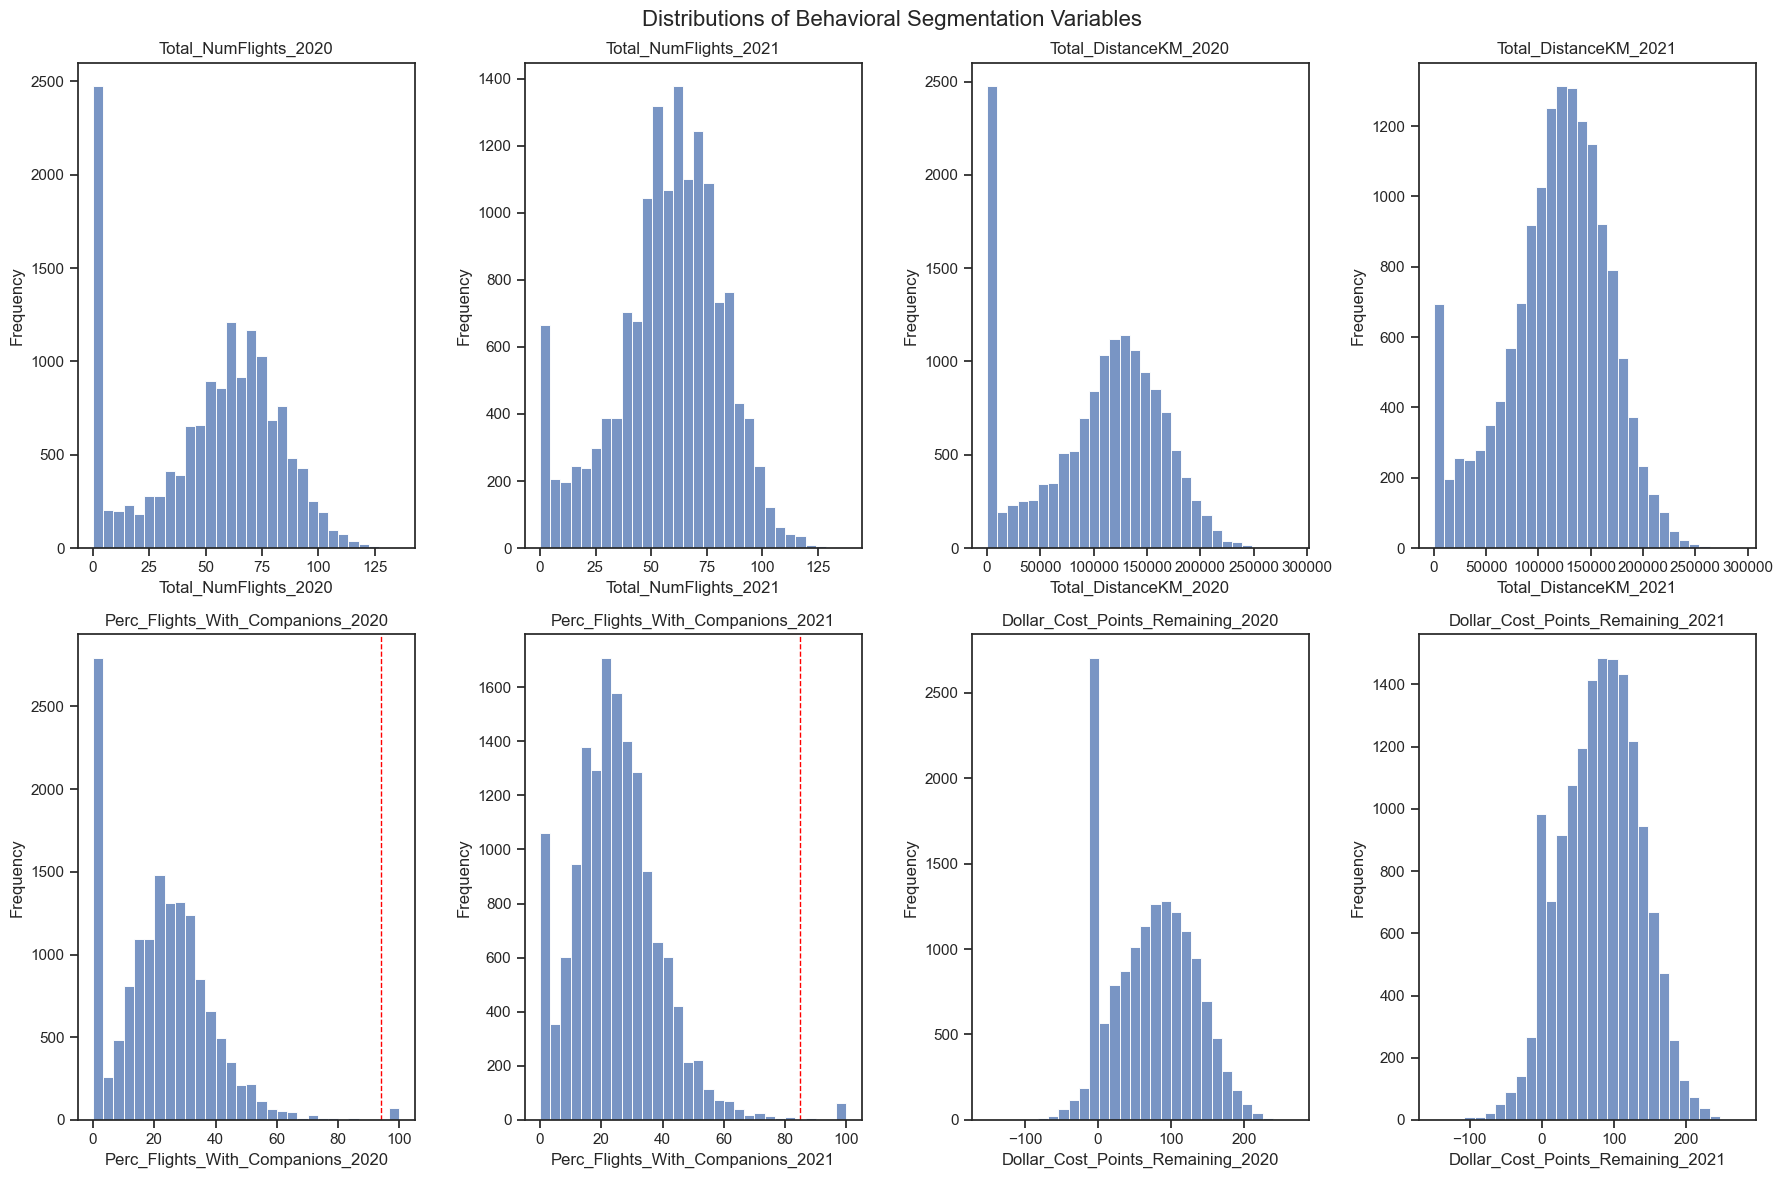

In [273]:
fig, axes = plt.subplots(2, 4, figsize=(18, 12))
axes = axes.flatten()

for ax, col in zip(axes, df_AIAI_Behavioral_year.columns):

    data = df_AIAI_Behavioral_year[col]

    # Compute IQR
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    # Extreme outlier bounds (3 × IQR)
    lower_extreme = q1 - 3 * iqr
    upper_extreme = q3 + 3 * iqr

    # Plot histogram
    sns.histplot(data, bins=30, ax=ax)

    # Plot extreme bounds ONLY if they are within data range
    if data.min() < lower_extreme:
        ax.axvline(lower_extreme, color='red', linestyle='--', linewidth=1)

    if data.max() > upper_extreme:
        ax.axvline(upper_extreme, color='red', linestyle='--', linewidth=1)

    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.suptitle("Distributions of Behavioral Segmentation Variables", fontsize=16)
plt.tight_layout()
plt.show()

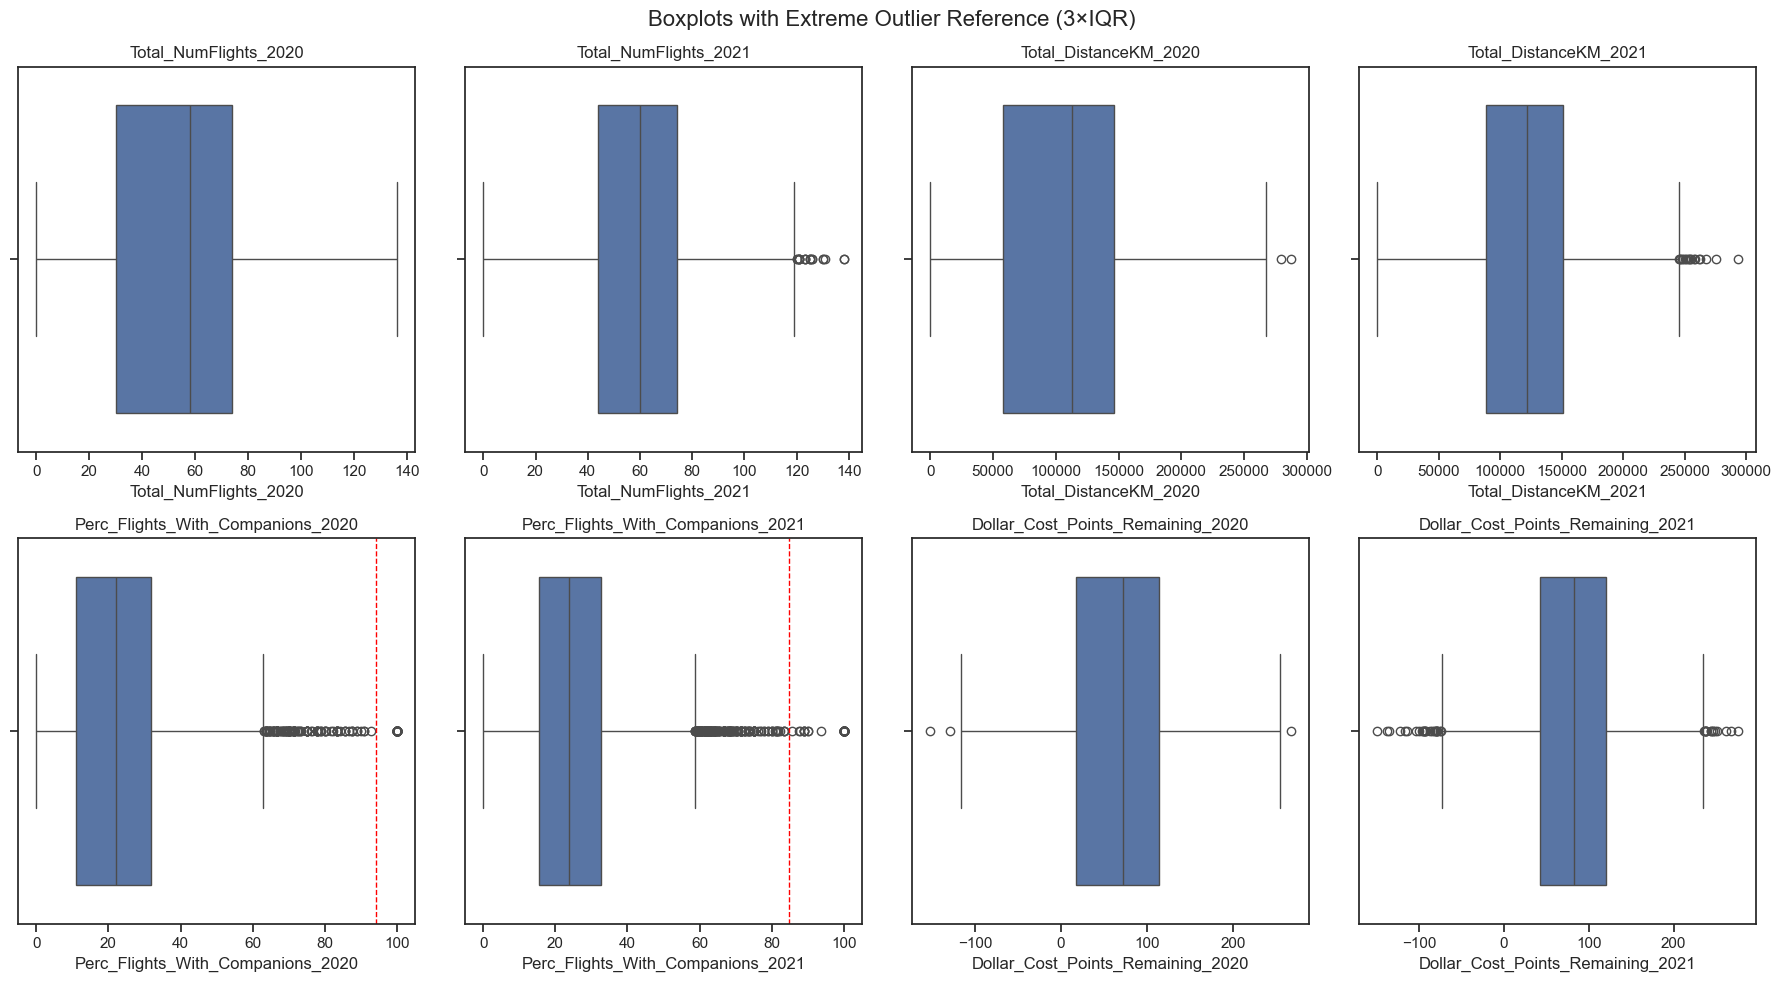

In [274]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, df_AIAI_Behavioral_year.columns):
    
    data = df_AIAI_Behavioral_year[col]
    
    # Compute IQR
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    
    # Extreme outlier bounds (3 × IQR)
    lower_extreme = q1 - 3 * iqr
    upper_extreme = q3 + 3 * iqr
    
    # Boxplot
    sns.boxplot(x=data, ax=ax)
    
    # Plot extreme bounds ONLY if they are within data range
    if data.min() < lower_extreme:
        ax.axvline(lower_extreme, color='red', linestyle='--', linewidth=1)
        
    if data.max() > upper_extreme:
        ax.axvline(upper_extreme, color='red', linestyle='--', linewidth=1)
    
    ax.set_title(col)
    ax.set_xlabel(col)

plt.suptitle(
    "Boxplots with Extreme Outlier Reference (3×IQR)",
    fontsize=16
)
plt.tight_layout()
plt.show()

We are not going to take out any outlier

## Scaling

In [275]:
scaler = MinMaxScaler(feature_range=(-1, 1))
df_for_modeling = pd.DataFrame(
    scaler.fit_transform(df_AIAI_Behavioral_year),
    index=df_AIAI_Behavioral_year.index,
    columns=df_AIAI_Behavioral_year.columns
)

In [276]:
df_for_modeling.head()

,Total_NumFlights_2020,Total_NumFlights_2021,Total_DistanceKM_2020,Total_DistanceKM_2021,Perc_Flights_With_Companions_2020,Perc_Flights_With_Companions_2021,Dollar_Cost_Points_Remaining_2020,Dollar_Cost_Points_Remaining_2021
Loyalty#,,,,,,,,
480934,-0.058824,-0.014493,-0.101322,0.723197,-0.406250,-0.411765,0.226085,0.470458
549612,0.455882,0.318841,-0.009243,-0.182000,-0.838384,-0.626374,0.084835,-0.191563
429460,-0.117647,-0.913043,-0.243667,-0.838942,-0.300000,-1.000000,0.105484,-0.184596
608370,0.191176,-0.391304,0.110715,-0.432093,-0.382716,-0.476190,0.160134,-0.062662
530508,-0.367647,0.289855,-0.021722,-0.318063,-0.023256,-0.483146,0.394993,0.174286


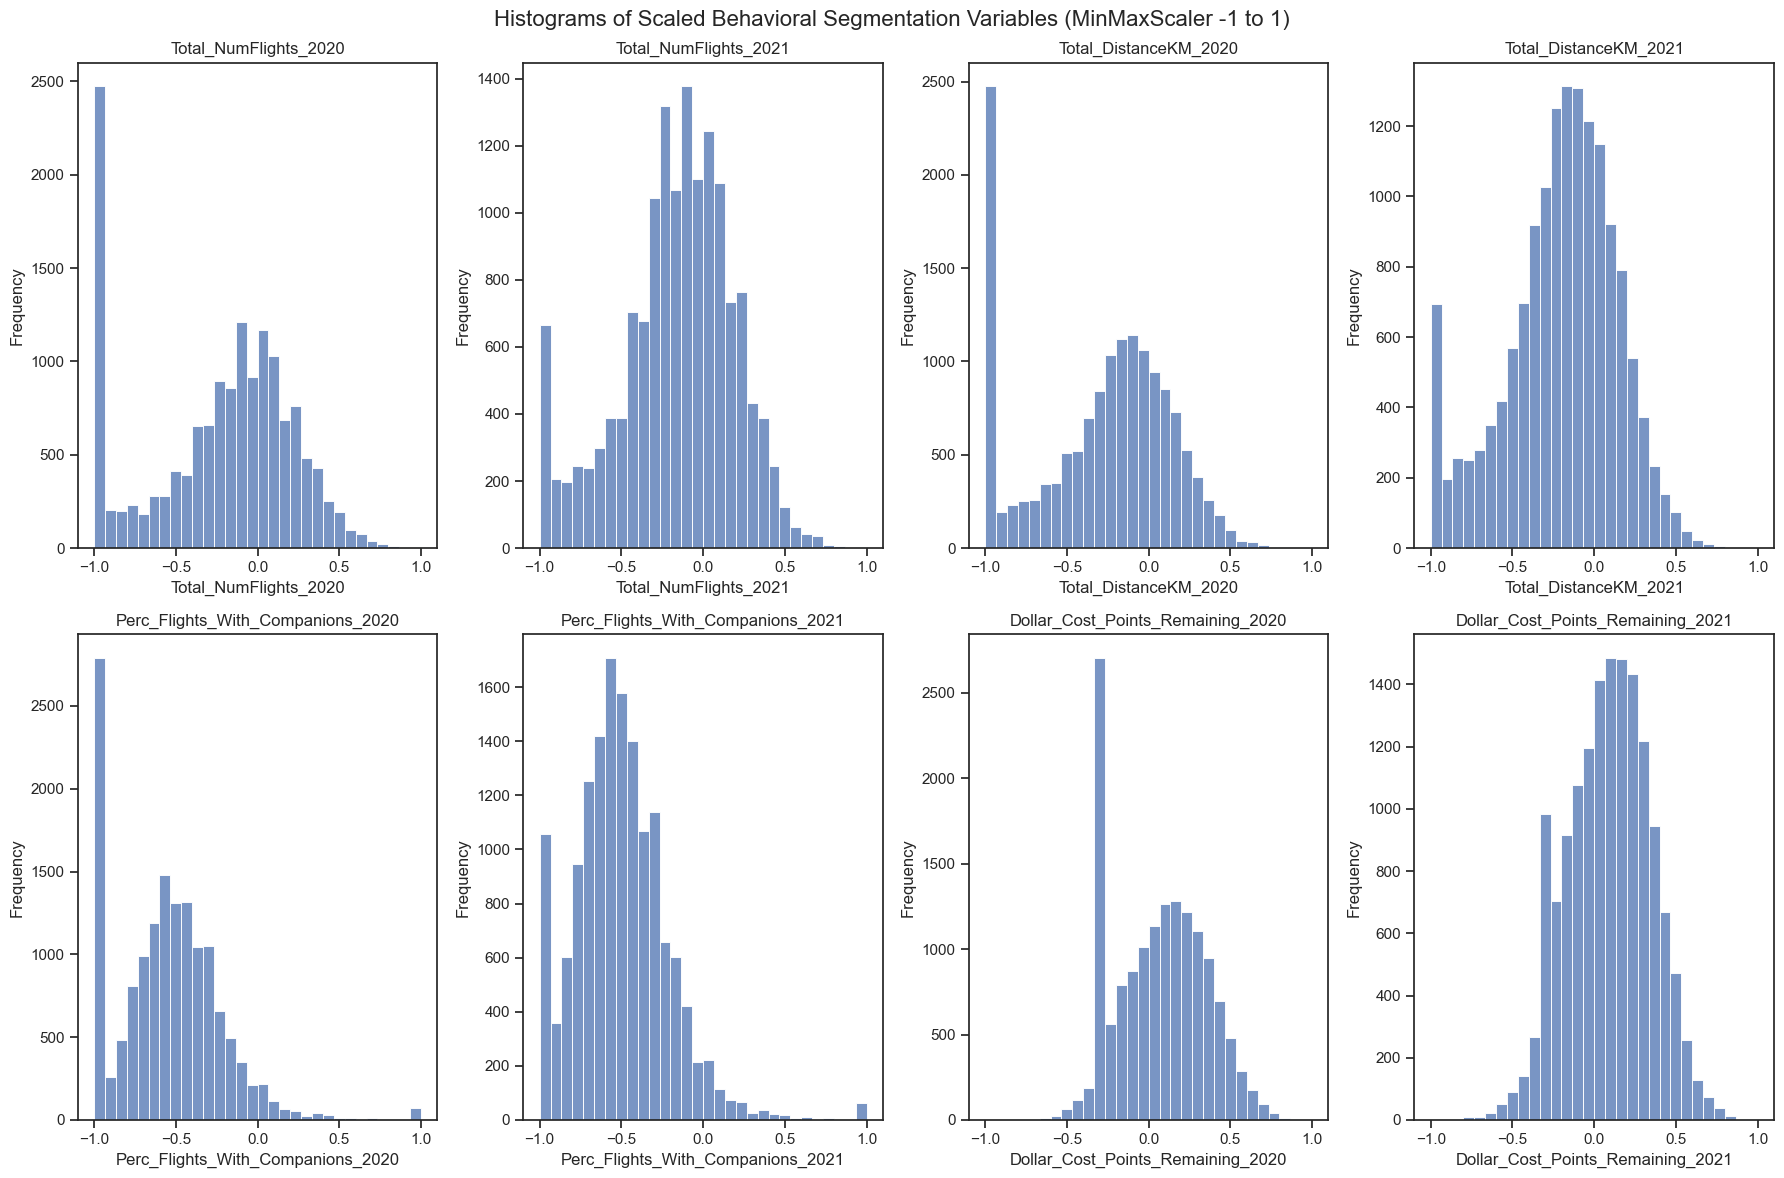

In [277]:
# Histograms of Scaled Variables
fig, axes = plt.subplots(2, 4, figsize=(18, 12))
axes = axes.flatten()

for ax, col in zip(axes, df_for_modeling.columns):
    sns.histplot(df_for_modeling[col], bins=30, ax=ax)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.suptitle("Histograms of Scaled Behavioral Segmentation Variables (MinMaxScaler -1 to 1)", fontsize=16)
plt.tight_layout()
plt.show()

In [278]:
X = df_for_modeling.values

# Compute SST once (constant for all clusterings)
sst_per_feature = np.sum(np.square(X - X.mean(axis=0)), axis=0)
sst = np.sum(sst_per_feature, axis=0)

results = []

for n_clusters in range(2, 11):  # Test from 2 to 10 clusters
    kmclust = KMeans(n_clusters=n_clusters, init='k-means++', random_state=22)
    labels = kmclust.fit_predict(df_for_modeling)
    
    # ---- SSW ----
    ssw = kmclust.inertia_
    
    # ---- SSB ----
    ssb_iter = []
    for i in np.unique(labels):
        X_k = X[labels == i]
        ssb_iter.append(X_k.shape[0] * np.square(X_k.mean(axis=0) - X.mean(axis=0)))
    ssb_per_feature = np.sum(ssb_iter, axis=0)
    ssb = np.sum(ssb_per_feature, axis=0)
    
    # ---- Silhouette ----
    sil_score = silhouette_score(X, labels)
    
    results.append({
        'num_clusters': n_clusters,
        'ssw (Lower is better, 0 to +∞)': ssw,
        'ssb (Higher is better, 0 to SST)': ssb,
        'silhouette_score (Higher is better, −1 to +1)': sil_score,
        'r2 (Higher is better, 0 to 1)': ssb / sst,
        
        
    })

df_cluster_metrics = pd.DataFrame(results)

In [279]:
df_cluster_metrics

,num_clusters,"ssw (Lower is better, 0 to +∞)","ssb (Higher is better, 0 to SST)","silhouette_score (Higher is better, −1 to +1)","r2 (Higher is better, 0 to 1)"
0,2,8949.187994,5488.883353,0.396568,0.380167
1,3,8021.657726,6416.431143,0.365349,0.444411
2,4,6851.131082,7586.944656,0.220296,0.525482
3,5,6170.571521,8267.509176,0.192725,0.572619
4,6,5820.794943,8617.286377,0.174445,0.596845
5,7,5581.327994,8856.819010,0.164267,0.613435
6,8,5100.491436,9337.586982,0.165211,0.646734
7,9,4911.352824,9526.720153,0.161703,0.659834
8,10,4765.474393,9672.605107,0.153133,0.669938


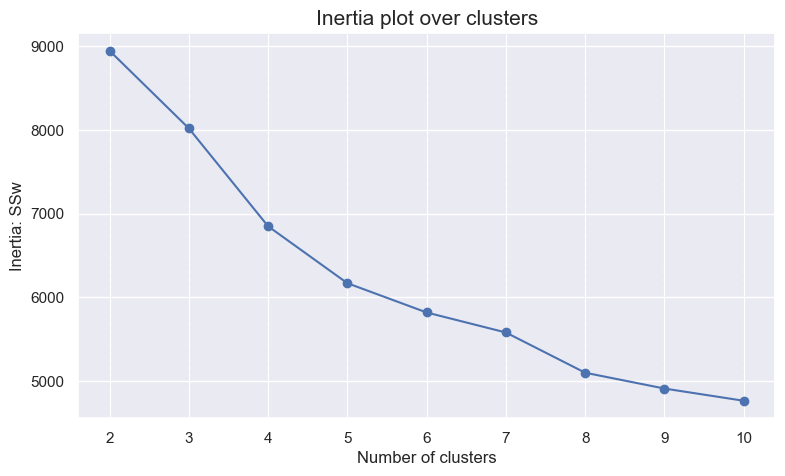

In [301]:
fig, ax = plt.subplots(figsize=(9,5))

range_clusters= list(range(2,11))
inertia= df_cluster_metrics['ssw (Lower is better, 0 to +∞)']
ax.plot(range_clusters, inertia, marker='o', zorder=2)
ax.set_xticks(list(range_clusters))

# draw vertical dashed background lines at each cluster number
for x in range_clusters:
    ax.axvline(x, color='lightgray', linestyle='--', linewidth=1, zorder=0, alpha=0.7)

ax.set_ylabel("Inertia: SSw")
ax.set_xlabel("Number of clusters")
ax.set_title("Inertia plot over clusters", size=15)

plt.show()

In [315]:
# final cluster solution with 5
number_clusters = 5
kmclust = KMeans(n_clusters=number_clusters, init='k-means++', random_state=22)
km_labels = kmclust.fit_predict(df_for_modeling)
km_labels

array([1, 1, 0, ..., 1, 1, 2], dtype=int32)

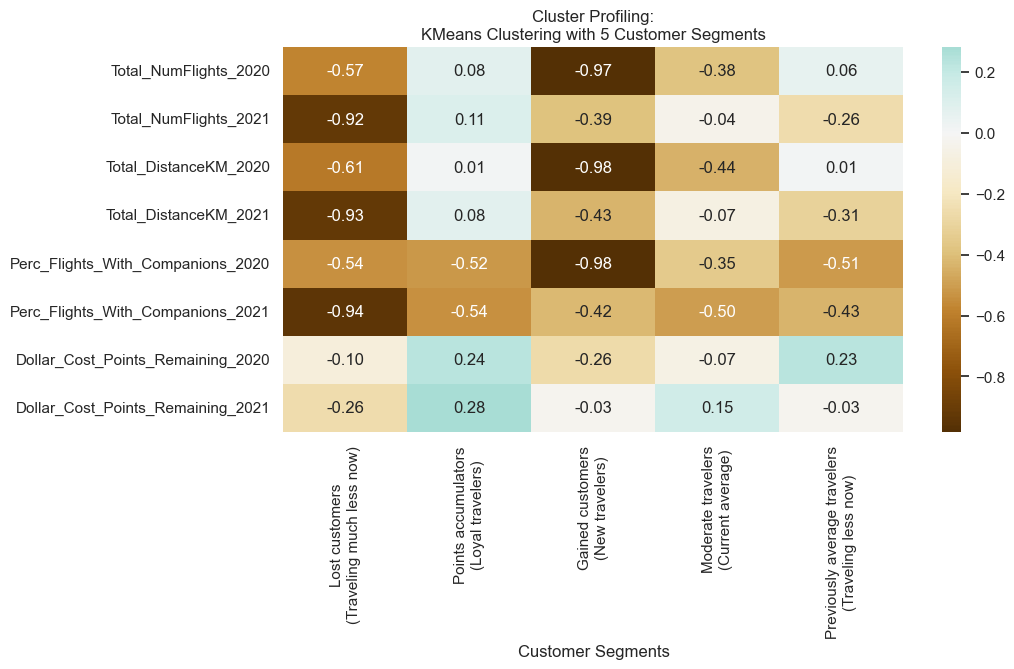

In [316]:
cluster_name_map = {
    0: "Lost customers\n(Traveling much less now)",
    1: "Points accumulators\n(Loyal travelers)",
    2: "Gained customers\n(New travelers)",
    3: "Moderate travelers\n(Current average)",
    4: "Previously average travelers\n(Traveling less now)"
}

df_concat = pd.concat(
    (df_for_modeling, pd.Series(km_labels, name='labels', index=df_for_modeling.index)),
    axis=1
)

fig, ax = plt.subplots(figsize=(10, 5))

# Compute cluster profiles
km_profile = df_concat.groupby('labels').mean().T

# Rename cluster columns using your mapping
km_profile = km_profile.rename(columns=cluster_name_map)

sns.heatmap(
    km_profile,
    center=0,
    annot=True,
    cmap="BrBG",
    fmt=".2f",
    ax=ax
)

ax.set_xlabel("Customer Segments")
ax.set_title("Cluster Profiling:\nKMeans Clustering with 5 Customer Segments")
plt.show()

In [317]:
df_concat['cluster_name'] = df_concat['labels'].map(cluster_name_map)

0- clientes perdidos, ya no hacen tantos viajes <br>
2- clientes ganados, antes no hacian viajes <br>
1- points accumulators, viajantes leales, <br>
3- gente que viaja moderadamente, viajante promedio de ahorita porque antes viajaba poco, acumuladores de puntos en su respectivo tiempo de viaje <br>
4 - gente viajante promedio anterior, antes viajaba como el promedio y ahorita no, acumuladores de puntos en su respectivo tiempo

In [318]:
df_concat['cluster_name'].value_counts()

cluster_name
Points accumulators\n(Loyal travelers)                4255
Previously average travelers\n(Traveling less now)    4009
Moderate travelers\n(Current average)                 3434
Gained customers\n(New travelers)                     2489
Lost customers\n(Traveling much less now)              914
Name: count, dtype: int64

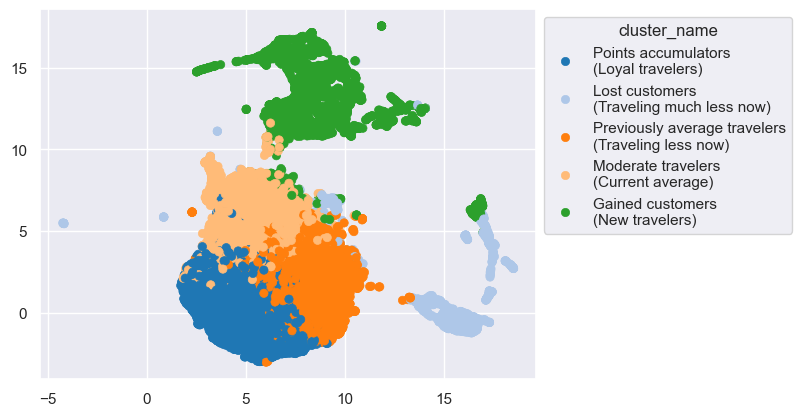

In [319]:
umap_original = umap.UMAP(n_neighbors = 5, random_state = 0).fit_transform(df_for_modeling)
targets = df_concat['cluster_name']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1],palette='tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

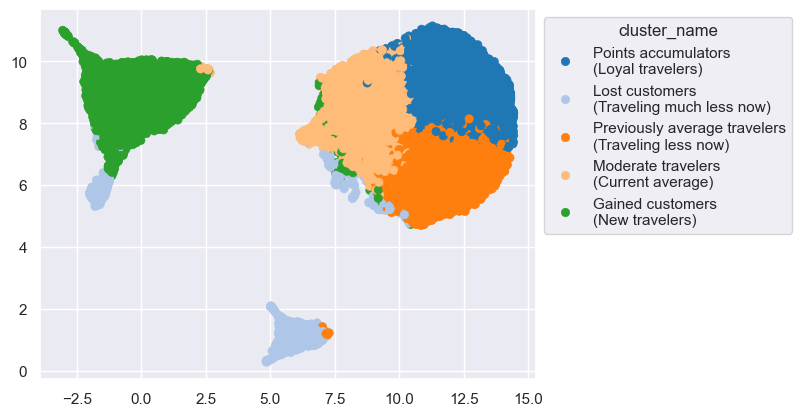

In [320]:
umap_original = umap.UMAP(n_neighbors = 50, random_state = 0).fit_transform(df_for_modeling)
targets = df_concat['cluster_name']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1], palette='tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [287]:
# final cluster solution with 8
number_clusters = 8
kmclust = KMeans(n_clusters=number_clusters, init='k-means++', random_state=22)
km_labels = kmclust.fit_predict(df_for_modeling)
km_labels

array([1, 5, 0, ..., 1, 1, 6], dtype=int32)

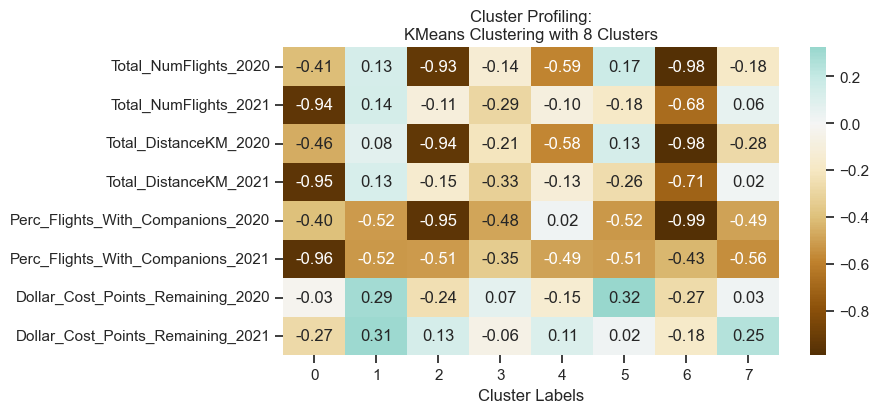

In [288]:
df_concat = pd.concat((df_for_modeling, pd.Series(km_labels, name='labels', index=df_for_modeling.index)), axis=1)

fig, ax = plt.subplots(figsize=(8,4))

km_profile = df_concat.groupby('labels').mean().T

sns.heatmap(km_profile,
            center=0, annot=True, cmap="BrBG", fmt=".2f",
            ax=ax 
            )

ax.set_xlabel("Cluster Labels")
ax.set_title("Cluster Profiling:\nKMeans Clustering with 8 Clusters")
plt.show()

0- viajantes perdidos, viajaba mas antes que ahora no viaja
 
1- promedio, se mantuviron, leal 

2- viajantes ganados, antes no viajaba ahora viaja promedio

3- viaja consistente, menos que el promedio y usa los puntos 

4- antes viajaba poco y ahorita es promedio

5- acumulador de puntos 2020

6- persona que viaja poco

7- acumulador de puntos 2021


In [289]:
df_concat['labels'].value_counts()

labels
7    3070
5    2681
1    2509
3    2346
6    1473
2    1448
4     914
0     660
Name: count, dtype: int64

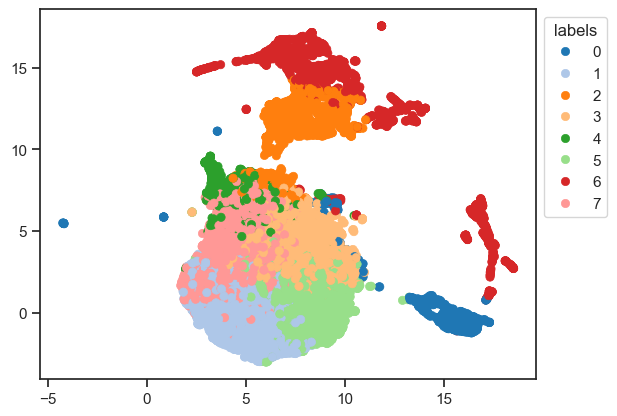

In [290]:
umap_original = umap.UMAP(n_neighbors = 5, random_state = 0).fit_transform(df_for_modeling)
targets = df_concat['labels']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1],palette='tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

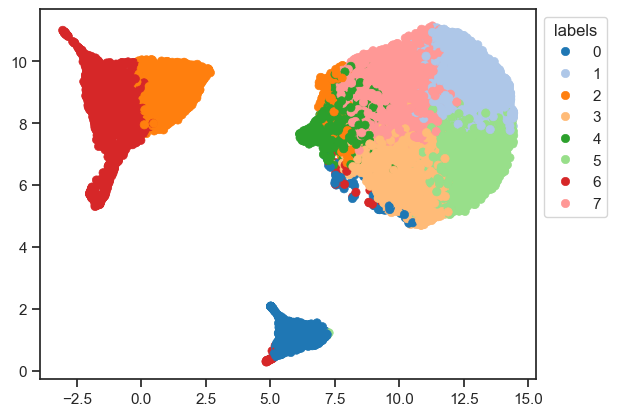

In [291]:
umap_original = umap.UMAP(n_neighbors = 50, random_state = 0).fit_transform(df_for_modeling)
targets = df_concat['labels']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1], palette='tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

In [292]:
linkage_matrix= linkage(df_for_modeling, method="ward")

In [293]:
linkage_matrix.shape

(15100, 4)

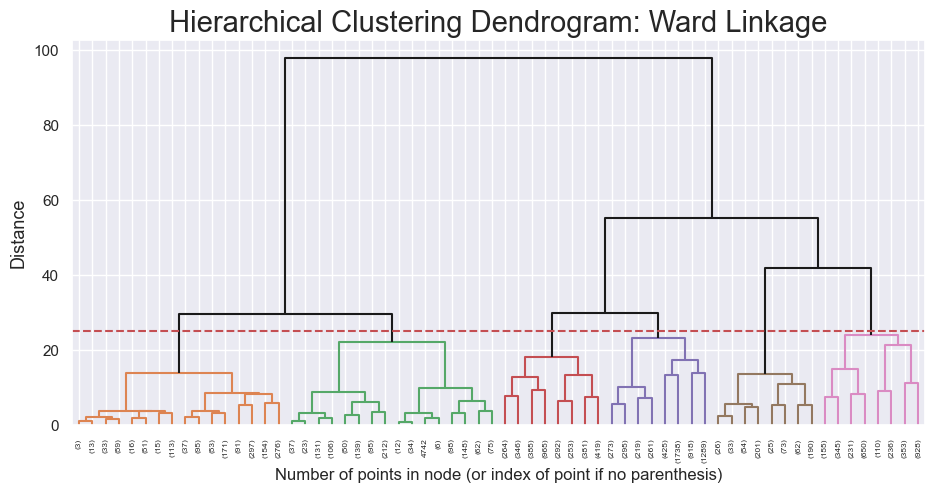

In [294]:
# Plot the corresponding dendrogram
sns.set()
fig = plt.figure(figsize=(11,5))
# The Dendrogram parameters need to be tuned
Y_THRESHOLD = 25
dendrogram(linkage_matrix, truncate_mode='level', p=5, color_threshold=Y_THRESHOLD, above_threshold_color='k')
    # You can play with 'truncate_mode' and 'p' define what level the dendrogram shows
    # above_threshold_color='k' forces black color for the lines above the threshold)
plt.hlines(Y_THRESHOLD, 0, 1000, colors="r", linestyles="dashed")
plt.title(f'Hierarchical Clustering Dendrogram: Ward Linkage', fontsize=21)
plt.xlabel('Number of points in node (or index of point if no parenthesis)')
plt.ylabel(f'Distance', fontsize=13)
plt.show()

In [295]:
# Performing HC
hclust = AgglomerativeClustering(linkage='ward', metric='euclidean', n_clusters=6)
hc_labels = hclust.fit_predict(df_for_modeling)
hc_labels

array([1, 1, 3, ..., 1, 1, 5])

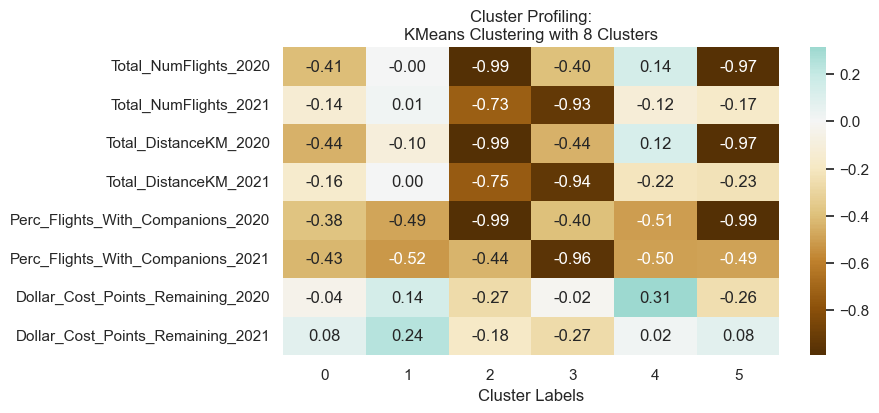

In [296]:
df_concat = pd.concat((df_for_modeling, pd.Series(hc_labels, name='labels', index=df_for_modeling.index)), axis=1)

fig, ax = plt.subplots(figsize=(8,4))

hc_profile = df_concat.groupby('labels').mean().T

sns.heatmap(hc_profile,
            center=0, annot=True, cmap="BrBG", fmt=".2f",
            ax=ax 
            )

ax.set_xlabel("Cluster Labels")
ax.set_title("Cluster Profiling:\nKMeans Clustering with 8 Clusters")
plt.show()

In [297]:
df_concat['labels'].value_counts()

labels
1    5418
4    3305
0    3008
5    1477
2    1229
3     664
Name: count, dtype: int64

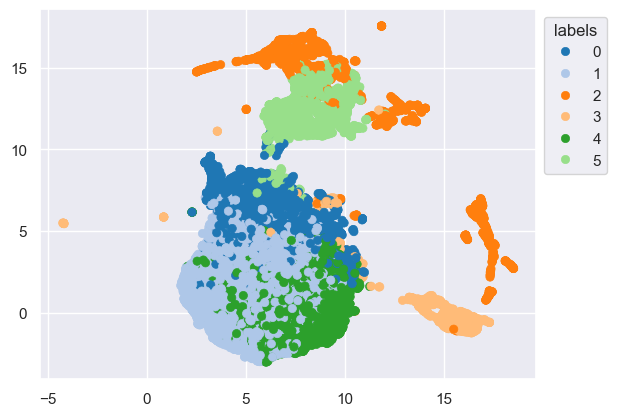

In [298]:
umap_original = umap.UMAP(n_neighbors = 5, random_state = 0).fit_transform(df_for_modeling)
targets = df_concat['labels']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1],palette='tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

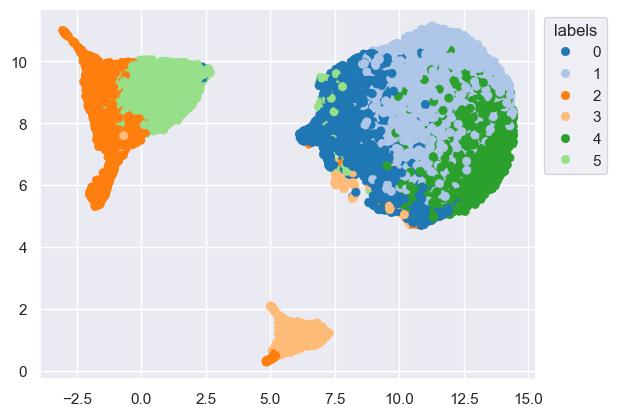

In [299]:
umap_original = umap.UMAP(n_neighbors = 50, random_state = 0).fit_transform(df_for_modeling)
targets = df_concat['labels']
ax = sns.scatterplot(x=umap_original[:, 0], y=umap_original[:, 1],palette='tab20',
                         hue=targets, legend='full', edgecolor=None)
sns.move_legend(ax, loc='upper left', bbox_to_anchor=(1, 1))
plt.show()